In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
import os
import pandas as pd

path = "/kaggle/input/datasets/virentambe/personalised-healthcare-dataset"

print(os.listdir(path))

df = pd.read_csv("/kaggle/input/datasets/virentambe/personalised-healthcare-dataset" + "/blood.csv")

df.head()

['blood.csv']


,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,99,1
1,0,13,3250,28,1
2,1,17,4000,36,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [4]:
df.shape

(748, 5)

In [5]:
df.columns

Index(['Recency', 'Frequency', 'Monetary', 'Time', 'Class'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    748 non-null    int64
 1   Frequency  748 non-null    int64
 2   Monetary   748 non-null    int64
 3   Time       748 non-null    int64
 4   Class      748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [7]:
df.describe()

,Recency,Frequency,Monetary,Time,Class
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.516043,1378.676471,34.284759,0.237968
std,8.095396,5.841825,1459.826781,24.380307,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,99.000000,1.000000


In [8]:
df.isnull().sum()

Recency      0
Frequency    0
Monetary     0
Time         0
Class        0
dtype: int64

In [9]:
df = df.dropna()

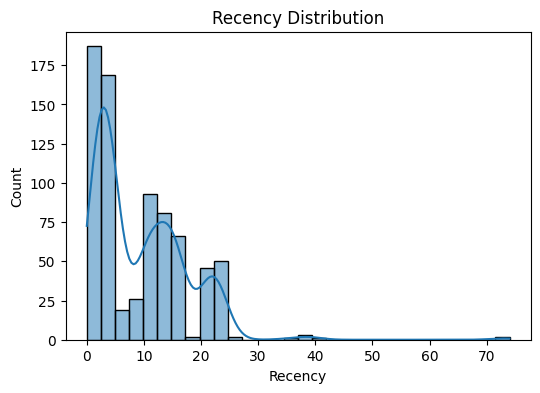

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['Recency'], kde=True)
plt.title("Recency Distribution")
plt.show()

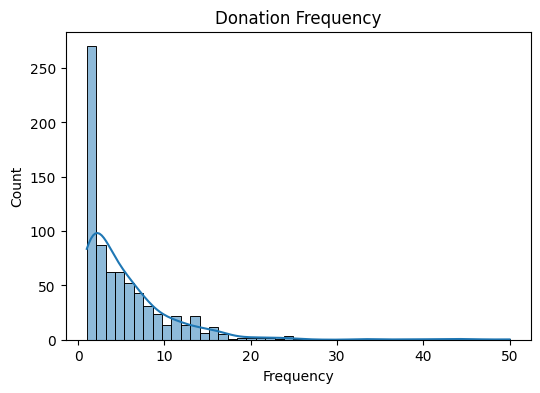

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['Frequency'], kde=True)
plt.title("Donation Frequency")
plt.show()

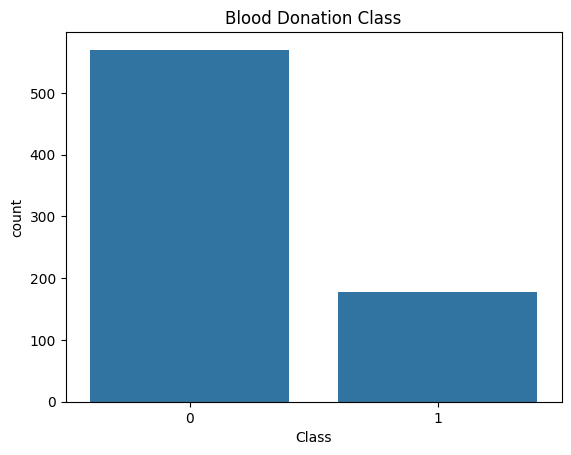

In [12]:
sns.countplot(x='Class', data=df)
plt.title("Blood Donation Class")
plt.show()

In [13]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,99,1
1,0,13,3250,28,1
2,1,17,4000,36,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [14]:
X = df.drop('Class', axis=1)   # Features
y = df['Class']                # Target

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.76
Confusion Matrix:
[[110   3]
 [ 33   4]]


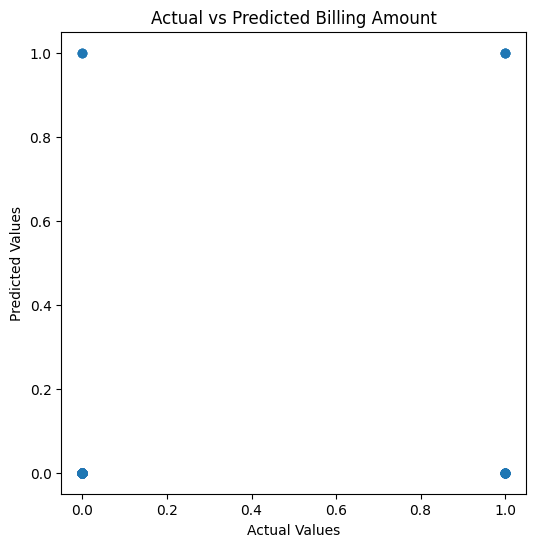

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Billing Amount")
plt.show()

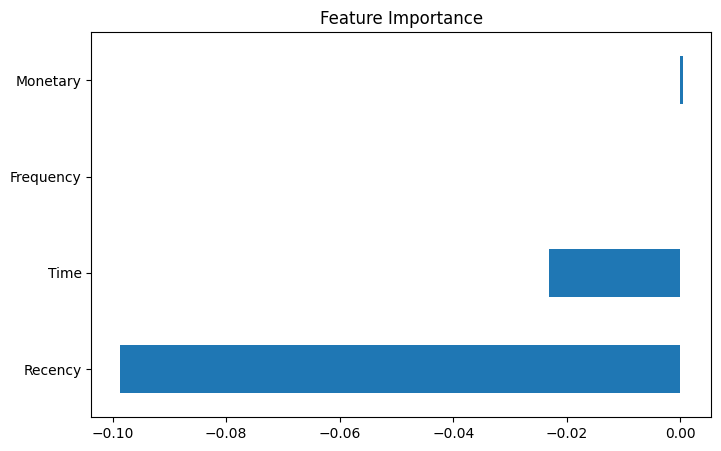

In [20]:
importance = model.coef_[0]

features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Importance")
plt.show()

## Final Business Insights

• Age and medical condition significantly influence healthcare billing.  
• Certain hospitals and doctors handle more expensive cases.  
• The machine learning model helps predict healthcare costs based on patient data.  
• Feature importance shows which factors impact billing the most.

This model can help hospitals estimate treatment costs and improve resource planning.